# Brain Tumor Binary Classification

### Imports & metadata

In [112]:
import os

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import random_split
import torch
import torch.optim as optim

from PIL import Image
import numpy as np
from sklearn.metrics import confusion_matrix
import random
import math
import matplotlib.pyplot as plt
import seaborn as sns

RAND_SEED = 18
tumor_img_dir = "../data/raw/bratc_bin_jpg/yes"
healthy_img_dir = "../data/raw/bratc_bin_jpg/no"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("NVIDIA Cuda available: ", torch.cuda.is_available())
print("GPU: ", torch.cuda.get_device_name(0)) 

NVIDIA Cuda available:  True
GPU:  NVIDIA GeForce GTX 1050 Ti


In [113]:
class BrainTumorDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")
        label = self.labels[idx]
        if self.transform:
            img = self.transform(img)
        return img, label

def get_image_paths_and_labels(tumor_dir, healthy_dir):
    tumor_paths = [os.path.join(tumor_dir, f) for f in os.listdir(tumor_dir) if f.lower().endswith('.jpg')]
    healthy_paths = [os.path.join(healthy_dir, f) for f in os.listdir(healthy_dir) if f.lower().endswith('.jpg')]
    
    image_paths = tumor_paths + healthy_paths
    labels = [1] * len(tumor_paths) + [0] * len(healthy_paths)
    
    return image_paths, labels

def visualize_random_batch(dataset, n=6, rand_seed=None, classes={0: "Healthy", 1: "Tumor"}):
    if rand_seed is not None:
        random.seed(rand_seed)
        torch.manual_seed(rand_seed)

    indices = random.sample(range(len(dataset)), n)
    imgs = []
    labels = []

    for idx in indices:
        img, label = dataset[idx]
        imgs.append(img)
        labels.append(label)

    imgs = torch.stack(imgs)
    labels = torch.tensor(labels)

    # Undo normalization
    imgs = imgs * 0.5 + 0.5

    cols = 6
    rows = math.ceil(n / cols)
    plt.figure(figsize=(cols * 2, rows * 2.5))
    for i in range(n):
        img_np = imgs[i].permute(1, 2, 0).numpy()
        label = labels[i].item()
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img_np)
        plt.title(classes.get(label, str(label)))
        plt.axis("off")
    plt.tight_layout()
    plt.show()

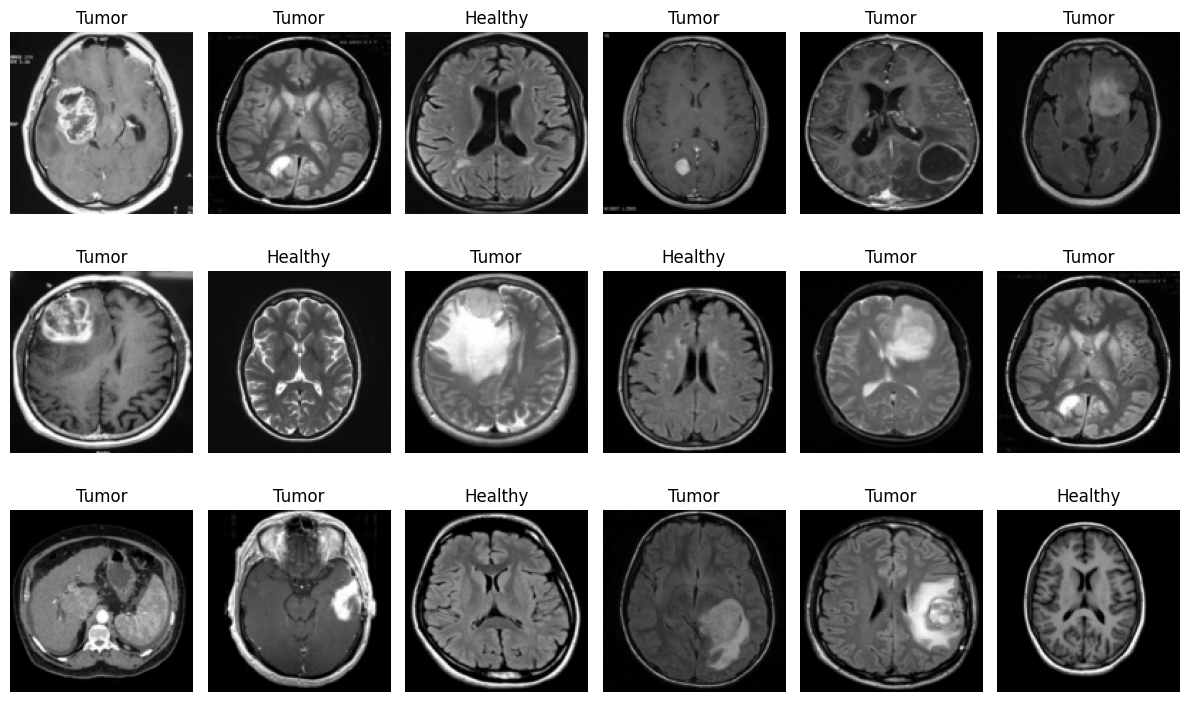

Total images: 245	Tumor (label=1): 154	Healthy (label=0): 91
Tensor shape:  torch.Size([3, 128, 128])


In [121]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

image_paths, labels = get_image_paths_and_labels(tumor_img_dir, healthy_img_dir)
dataset = BrainTumorDataset(image_paths, labels, transform=transform)

visualize_random_batch(dataset, n=18, rand_seed=RAND_SEED)

num_tumor = sum(1 for label in labels if label == 1)
num_healthy = sum(1 for label in labels if label == 0)
print(f"Total images: {len(labels)}\tTumor (label=1): {num_tumor}\tHealthy (label=0): {num_healthy}")
print("Tensor shape: ", dataset[0][0].shape)

In [91]:
class BraTClassCNN(nn.Module):
    def __init__(self):
        super(BraTClassCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1) # padding 1 keeps size
        self.pool = nn.MaxPool2d(2, 2) # kernel 2, stride 2
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(32*32*32, 128)
        self.fc2 = nn.Linear(128, 1)  # Binary classification

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x))) # 3 channels 128x128 -> 16 filters 64x64
        x = self.pool(F.relu(self.conv2(x))) # 16 channels 64x64 -> 32 filters 32x32
        x = x.view(-1, 32*32*32) # Flatten
        x = F.relu(self.fc1(x)) # 32 channels 32x32 -> 128
        x = torch.sigmoid(self.fc2(x)) # [0, 1]
        return x

In [108]:
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

model = BraTClassCNN().to(device)

criterion = nn.BCELoss()  # Binary Cross-Entropy
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.float().to(device).unsqueeze(1)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {running_loss / len(train_loader):.4f}")

model.eval()
correct = 0
total = 0

incorrectly_classified_imgs = []
all_preds = []
all_labels = []

with torch.inference_mode():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device).unsqueeze(1).float()
        outputs = model(images)
        pred = (outputs > 0.5).float()
        
        correct += (pred == labels).sum().item()
        total += labels.size(0)
        all_preds.extend(pred.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        for i in range(images.size(0)):
            if pred[i] != labels[i]:
                incorrectly_classified_imgs.append((
                    images[i].cpu(),
                    pred[i].item(),
                    labels[i].item()
                ))

print(f"Validation Accuracy: {100 * correct / total:.2f}%")

Epoch 1, Loss: 0.8173
Epoch 2, Loss: 0.5616
Epoch 3, Loss: 0.4860
Epoch 4, Loss: 0.4334
Epoch 5, Loss: 0.3736
Epoch 6, Loss: 0.3398
Epoch 7, Loss: 0.2980
Epoch 8, Loss: 0.2083
Epoch 9, Loss: 0.1726
Epoch 10, Loss: 0.1235
Validation Accuracy: 89.80%


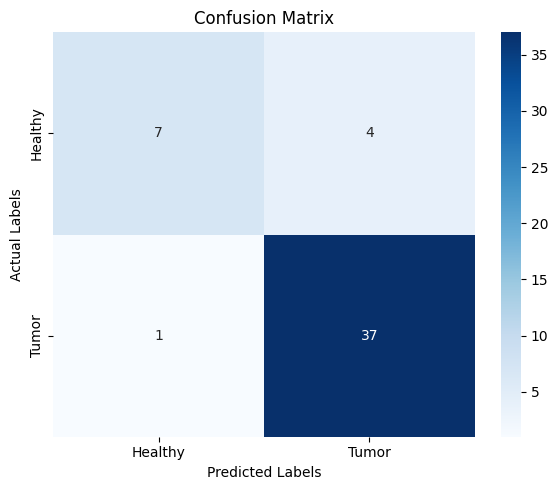

In [130]:
def plot_confusion_matrix(predicted, actual, class_names=None):
    cm = confusion_matrix(actual, predicted)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted Labels')
    plt.ylabel('Actual Labels')
    plt.title('Confusion Matrix')
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(all_preds, all_labels, class_names=["Healthy", "Tumor"])

#### Incorrectly classified images

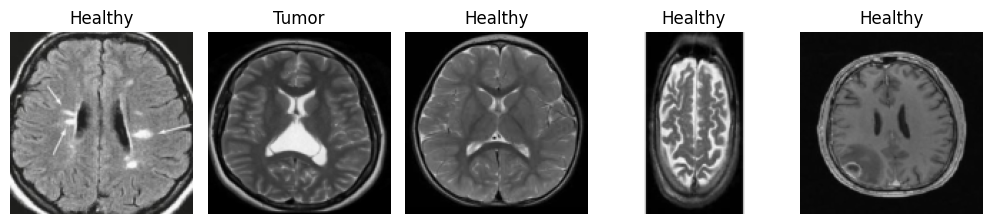

In [127]:
visualize_random_batch([(i[0], i[2]) for i in incorrectly_classified_imgs], n=len(incorrectly_classified_imgs), rand_seed=RAND_SEED)